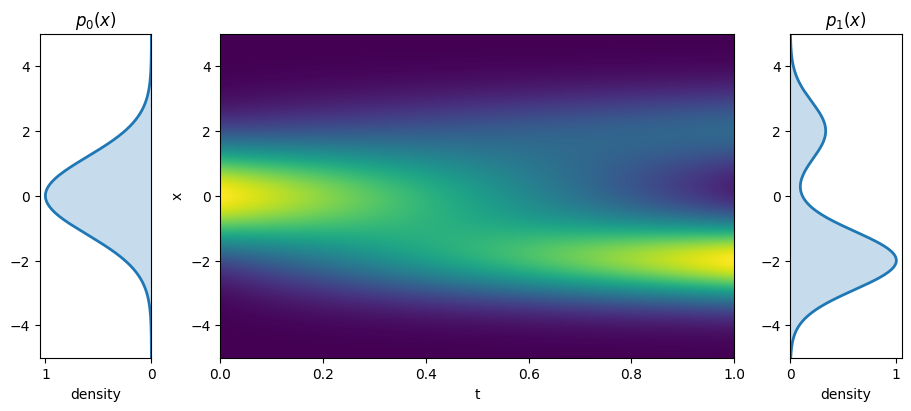

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

def normal_pdf(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (np.sqrt(2*np.pi) * sigma)

def p0(x):
    # Left endpoint: single Gaussian
    return normal_pdf(x, mu=0.0, sigma=1.2)

def p1(x):
    # Right endpoint: mixture of two Gaussians of different sizes (weights + widths)
    w = 0.75
    return w * normal_pdf(x, mu=-2, sigma=0.9) + (1-w) * normal_pdf(x, mu=2, sigma=0.9)

def p_t(t, x):
    # Simple interpolation of densities for visualization
    return (1.0 - t) * p0(x) + t * p1(x)

def make_plot():
    # Grid for x and t
    xs = np.linspace(-5, 5, 400)
    ts = np.linspace(0, 1, 300)

    # Density grid P[x_index, t_index]
    P = np.stack([p_t(t, xs) for t in ts], axis=1)

    # Endpoint curves (normalize just for nicer side-curve sizing)
    pL = P[:, 0]
    pR = P[:, -1]
    pL = pL / (pL.max() + 1e-12)
    pR = pR / (pR.max() + 1e-12)

    fig = plt.figure(figsize=(9, 4), constrained_layout=True)
    gs = GridSpec(1, 3, figure=fig, width_ratios=[1.3, 6.0, 1.3], wspace=0.05)

    axL = fig.add_subplot(gs[0, 0])
    axM = fig.add_subplot(gs[0, 1], sharey=axL)
    axR = fig.add_subplot(gs[0, 2], sharey=axL)

    # --- Middle heatmap ---
    im = axM.imshow(
        P,
        origin="lower",
        aspect="auto",
        extent=[ts[0], ts[-1], xs[0], xs[-1]],
        cmap="viridis",
        interpolation="bilinear",
    )
    axM.set_xlabel("t")
    axM.set_ylabel("x")
    #fig.colorbar(im, ax=axM, label=r"$p_t(x)$")

    # --- Left curve (p0) ---
    axL.fill_betweenx(xs, 0, pL, alpha=0.25)
    axL.plot(pL, xs, lw=2)
    axL.set_title(r"$p_0(x)$")
    axL.set_xlabel("density")
    axL.invert_xaxis()  # makes it bulge outward to the left (like the diagram style)
    axL.set_xlim(1.05, 0)

    # --- Right curve (p1) ---
    axR.fill_betweenx(xs, 0, pR, alpha=0.25)
    axR.plot(pR, xs, lw=2)
    axR.set_title(r"$p_1(x)$")
    axR.set_xlabel("density")
    axR.set_xlim(0, 1.05)

    plt.show()

if __name__ == "__main__":
    make_plot()